Workshop-4: Training GAN for MNIST dataset

In [2]:
# import necessary python packages

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
from torchvision.utils import save_image

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
#Download the MNIST dataset and do pre-processing

bs = 100

# MNIST Dataset

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transform, download=False)


# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=bs, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=bs, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 143MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 27.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 68.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.62MB/s]


In [4]:
# Define the architectures for Generator and Disciminator

class Generator(nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(g_input_dim, 256)
        self.fc2 = nn.Linear(self.fc1.out_features, self.fc1.out_features*2)
        self.fc3 = nn.Linear(self.fc2.out_features, self.fc2.out_features*2)
        self.fc4 = nn.Linear(self.fc3.out_features, g_output_dim)

    # forward method
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = F.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))

class Discriminator(nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(d_input_dim, 1024)
        self.fc2 = nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = nn.Linear(self.fc3.out_features, 1)

    # forward method
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = F.dropout(x, 0.3)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = F.dropout(x, 0.3)
        x = F.leaky_relu(self.fc3(x), 0.2)
        x = F.dropout(x, 0.3)
        return torch.sigmoid(self.fc4(x))

In [8]:
# Create instance for the Generator and Discriminator
# Set the dimension of the Gaussian noise to be 100 in Generator
# Set the dimension of the real data samples to be 784 in both Generator and Discriminator
# Put the two DNN models to device as defined earlier.

z_dim = 100
mnist_dim = train_dataset.train_data.size(1) * train_dataset.train_data.size(2)
print(mnist_dim)

G = Generator(g_input_dim = z_dim, g_output_dim = mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)

784


In [19]:
G

Generator(
  (fc1): Linear(in_features=100, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=1024, bias=True)
  (fc4): Linear(in_features=1024, out_features=784, bias=True)
)

In [ ]:
D

Discriminator(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=1, bias=True)
)

In [9]:
# define loss function
criterion = nn.BCELoss()

# optimizer
lr = 0.0002
G_optimizer = optim.Adam(G.parameters(), lr = lr)
D_optimizer = optim.Adam(D.parameters(), lr = lr)

In [10]:
def D_train(x):
    #=======================Train the discriminator=======================#
    D.zero_grad()

    # train discriminator on real
    x_real, y_real = x.view(-1, mnist_dim), torch.ones(bs, 1)
    x_real, y_real = Variable(x_real.to(device)), Variable(y_real.to(device))

    D_output = D(x_real)
    D_real_loss = criterion(D_output, y_real)
    D_real_score = D_output

    # train discriminator on fake
    z = Variable(torch.randn(bs, z_dim).to(device))
    x_fake, y_fake = G(z), Variable(torch.zeros(bs, 1).to(device))

    D_output = D(x_fake)
    D_fake_loss = criterion(D_output, y_fake)
    D_fake_score = D_output

    # gradient backprop & optimize ONLY D's parameters
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()

    return  D_loss.data.item()

In [11]:
def G_train(x):
    #=======================Train the generator=======================#
    G.zero_grad()

    z = Variable(torch.randn(bs, z_dim).to(device))
    y = Variable(torch.ones(bs, 1).to(device))

    G_output = G(z)
    D_output = D(G_output)
    G_loss = criterion(D_output, y)

    # gradient backprop & optimize ONLY G's parameters
    G_loss.backward()
    G_optimizer.step()

    return G_loss.data.item()

In [12]:
n_epoch = 200
for epoch in range(1, n_epoch+1):
    D_losses, G_losses = [], []
    for batch_idx, (x, _) in enumerate(train_loader):
        D_losses.append(D_train(x))
        G_losses.append(G_train(x))

    print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            (epoch), n_epoch, torch.mean(torch.FloatTensor(D_losses)), torch.mean(torch.FloatTensor(G_losses))))

[1/200]: loss_d: 1.323, loss_g: 1.058
[2/200]: loss_d: 0.880, loss_g: 3.249
[3/200]: loss_d: 0.703, loss_g: 2.760
[4/200]: loss_d: 0.658, loss_g: 2.766
[5/200]: loss_d: 0.712, loss_g: 2.356
[6/200]: loss_d: 0.661, loss_g: 2.438
[7/200]: loss_d: 0.727, loss_g: 2.211
[8/200]: loss_d: 0.612, loss_g: 2.499
[9/200]: loss_d: 0.644, loss_g: 2.427
[10/200]: loss_d: 0.657, loss_g: 2.380
[11/200]: loss_d: 0.726, loss_g: 2.358
[12/200]: loss_d: 0.696, loss_g: 2.228
[13/200]: loss_d: 0.721, loss_g: 2.086
[14/200]: loss_d: 0.665, loss_g: 2.292
[15/200]: loss_d: 0.667, loss_g: 2.271
[16/200]: loss_d: 0.681, loss_g: 2.375
[17/200]: loss_d: 0.683, loss_g: 2.366
[18/200]: loss_d: 0.623, loss_g: 2.403
[19/200]: loss_d: 0.607, loss_g: 2.424
[20/200]: loss_d: 0.641, loss_g: 2.322
[21/200]: loss_d: 0.656, loss_g: 2.360
[22/200]: loss_d: 0.627, loss_g: 2.410
[23/200]: loss_d: 0.631, loss_g: 2.480
[24/200]: loss_d: 0.644, loss_g: 2.501
[25/200]: loss_d: 0.621, loss_g: 2.385
[26/200]: loss_d: 0.639, loss_g: 2

tensor(0.9973)
tensor(-0.6780)


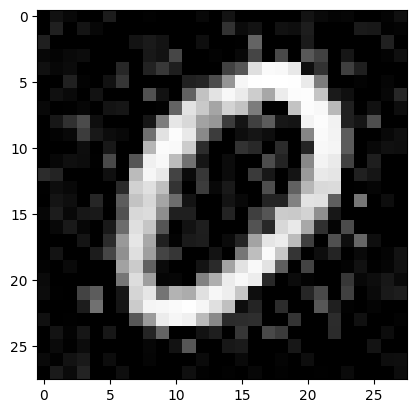

In [18]:
import matplotlib.pyplot as plt
with torch.no_grad():
    test_z = Variable(torch.randn(bs, z_dim).to(device))
    generated = G(test_z)


    plt.imshow(generated[1,:].to('cpu').view(28, 28), cmap='gray', vmin=0, vmax=1)

    plt.show()
